<a href="https://colab.research.google.com/github/DianaBravoPerez/EDP-1/blob/main/3.Parcial_Simulacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tercer parcial

1. **Línea de espera con 2 servidores en serie**
2. **Variables antitéticas** para estimar la integral de 0 a 1 de $e^{x^2}$
3. **Bootstrap y Jackknife**


---
# 1. Dos servidores


Imaginamos dos cajas en fila. Cuando llega un cliente:

1. Primero lo atiende la **caja 1**. Si está ocupada, hace fila
2. Cuando termina en la caja 1, **pasa a la caja 2**. Si está ocupada, hace fila
3. Cuando termina en la caja 2, **se va**

Como nadie se adelanta, el primer cliente que llega es el primero que sale, el segundo que llega es el segundo que sale, etc

### ¿Cómo lo vamos a simular?

En vez de mover el reloj poco a poco, **saltamos directo al siguiente momento en que pasa algo**. A esos "algos" les llamamos eventos. En este sistema solo pueden pasar tres cosas:

- **`t_A`**: el momento en que llega el siguiente cliente
- **`t1`**: el momento en que la caja 1 termina con quien está atendiendo
- **`t2`**: el momento en que la caja 2 termina con quien está atendiendo

En cada paso miramos cuál de los tres ocurre primero (el más pequeño) y actualizamos todo. Si una caja está vacía, su tiempo lo ponemos en infinito (`INF`) para que "no ocurra"

Guardamos también:
- `n1`: cuántos clientes hay en la caja 1, y `n2`: cuántos en la caja 2
- `llegadas`: la hora en que llegó cada cliente
- `salidas`: la hora en que se fue cada cliente


### Supuestos

Para que el ejemplo sea fácil suponemos que el tiempo entre llegadas y los tiempos de atención son exponenciales. Generamos un tiempo exponencial con `np.random.exponential`. Para que no se acumule la fila sin control, cada caja debe ser más rápida que las llegadas


In [ ]:
import numpy as np

# Devuelve un tiempo exponencial. Su promedio es 1/tasa.
def exponencial(tasa):
    return np.random.exponential(1.0 / tasa)

### PROGRAMA:

Seguimos los tres casos del libro de Ross:

- **Caso 1 (llega alguien):** sube `n1`; guardamos su hora de llegada, preparamos la siguiente llegada, si la caja 1 estaba vacía, empieza a atenderlo
- **Caso 2 (termina la caja 1):** ese cliente pasa a la caja 2 (`n1` baja, `n2` sube), se acomodan las cajas
- **Caso 3 (termina la caja 2):** ese cliente se va, guardamos su hora de salida


In [ ]:
def simular(lam, mu1, mu2, T, semilla=0):
    np.random.seed(semilla)
    INF = float('inf')

    # valores iniciales
    t = 0.0          # reloj
    n1 = 0           # clientes en la caja 1
    n2 = 0           # clientes en la caja 2
    llegadas = []    # hora de llegada de cada cliente
    salidas = []     # hora de salida de cada cliente

    t_A = exponencial(lam)   # hora de la primera llegada
    t1 = INF                 # la caja 1 empieza vacia
    t2 = INF                 # la caja 2 empieza vacia

    # mientras quede algun evento por ocurrir
    while min(t_A, t1, t2) < INF:
        siguiente = min(t_A, t1, t2)   # el evento mas proximo

        # ---- Caso 1: llega un cliente ----
        if siguiente == t_A:
            t = t_A
            n1 = n1 + 1
            llegadas.append(t)
            # preparar la siguiente llegada (si pasa de T, ya no hay mas)
            proxima = t + exponencial(lam)
            if proxima <= T:
                t_A = proxima
            else:
                t_A = INF
            # si la caja 1 estaba vacia, empieza a atender
            if n1 == 1:
                t1 = t + exponencial(mu1)

        # ---- Caso 2: termina la caja 1 ----
        elif siguiente == t1:
            t = t1
            n1 = n1 - 1
            n2 = n2 + 1
            if n1 == 0:
                t1 = INF
            else:
                t1 = t + exponencial(mu1)
            if n2 == 1:
                t2 = t + exponencial(mu2)

        # ---- Caso 3: termina la caja 2 (el cliente se va) ----
        else:
            t = t2
            n2 = n2 - 1
            salidas.append(t)
            if n2 == 0:
                t2 = INF
            else:
                t2 = t + exponencial(mu2)

    return llegadas, salidas

Usamos: llegadas con tasa `lam = 1`, caja 1 con `mu1 = 1.5`, caja 2 con `mu2 = 1.2`, y dejamos correr hasta `T = 5000`


In [ ]:
lam = 1.0
mu1 = 1.5
mu2 = 1.2
T = 5000.0

llegadas, salidas = simular(lam, mu1, mu2, T, semilla=1)

print("Clientes que llegaron:", len(llegadas))
print("Clientes que salieron:", len(salidas))

# tiempo en el sistema de cada cliente = hora de salida - hora de llegada
# (el cliente i que llega es el cliente i que sale)
tiempos = []
for i in range(len(salidas)):
    tiempos.append(salidas[i] - llegadas[i])

# promedio con un bucle sencillo
suma = 0.0
for x in tiempos:
    suma = suma + x
promedio = suma / len(tiempos)

print("Tiempo promedio que un cliente pasa en el sistema:", round(promedio, 4))

Clientes que llegaron: 5017
Clientes que salieron: 5017
Tiempo promedio que un cliente pasa en el sistema: 6.3919


### ¿Está bien?

Cada caja por separado es una cola sencilla, y su tiempo promedio teórico es `1 / (mu - lam)`. El tiempo total esperado es la suma de las dos cajas. Comparamos para ver si la simulación da algo parecido


In [ ]:
teorico = 1.0 / (mu1 - lam) + 1.0 / (mu2 - lam)

print("Tiempo promedio simulado:", round(promedio, 4))
print("Tiempo promedio teorico :", round(teorico, 4))

Tiempo promedio simulado: 6.3919
Tiempo promedio teorico : 7.0


Programamos el sistema de dos cajas en serie siguiendo los tres casos de Ross. El tiempo promedio simulado se parece al teórico, así que la simulación funciona. La caja 2 por ser más lenta, es donde se pasa más tiempo


---
# 2. Variables antitéticas

Calcular esta integral usando simulación:

$$\int_0^1 e^{x^2}\, dx$$




In [ ]:
import numpy as np

# la funcion que queremos integrar
def g(x):
    return np.exp(x**2)

# Valor "verdadero" para comparar: promedio de g en muchos puntos parejos de 0 a 1
puntos = np.linspace(0.0, 1.0, 1_000_001)
verdadero = g(puntos).mean()
print("Valor aproximado verdadero de la integral:", verdadero)

Valor aproximado verdadero de la integral: 1.4626521423964063


### Monte Carlo normal

Sacamos `n` números al azar entre 0 y 1, les aplicamos `g` y promediamos


In [ ]:
np.random.seed(0)
n = 5000

suma = 0.0
for i in range(n):
    u = np.random.random()
    suma = suma + g(u)
estimacion_normal = suma / n

print("Estimacion Monte Carlo normal:", estimacion_normal)

Estimacion Monte Carlo normal: 1.4593250386378291


### Monte Carlo con variables antitéticas

Ahora usamos pares: para cada número `u` usamos también `1 - u`. Para gastar la misma cantidad de evaluaciones, hacemos `n/2` pares


In [ ]:
suma = 0.0
for i in range(n // 2):
    u = np.random.random()
    # promediamos la funcion en u y en su espejo 1-u
    suma = suma + (g(u) + g(1 - u)) / 2
estimacion_anti = suma / (n // 2)

print("Estimacion antitetica:", estimacion_anti)

Estimacion antitetica: 1.46606881249595


### ¿Es más estable?

Para verlo, repetimoss cada método muchas veces y guardamos sus resultados. Luego medimos qué tanto "brincan" con `np.std` (desviación estándar): el que tiene menos varianza es el más estable


In [ ]:
np.random.seed(1)
repeticiones = 300

resultados_normal = []
resultados_anti = []

for r in range(repeticiones):
    # --- metodo normal ---
    suma = 0.0
    for i in range(n):
        u = np.random.random()
        suma = suma + g(u)
    resultados_normal.append(suma / n)

    # --- metodo antitetico ---
    suma = 0.0
    for i in range(n // 2):
        u = np.random.random()
        suma = suma + (g(u) + g(1 - u)) / 2
    resultados_anti.append(suma / (n // 2))

desv_normal = np.std(resultados_normal)
desv_anti = np.std(resultados_anti)

print("Que tanto brinca el metodo normal     :", round(desv_normal, 5))
print("Que tanto brinca el metodo antitetico :", round(desv_anti, 5))
print("El antitetico brinca como", round(desv_normal / desv_anti, 2), "veces menos.")

Que tanto brinca el metodo normal     : 0.00687
Que tanto brinca el metodo antitetico : 0.00309
El antitetico brinca como 2.23 veces menos.


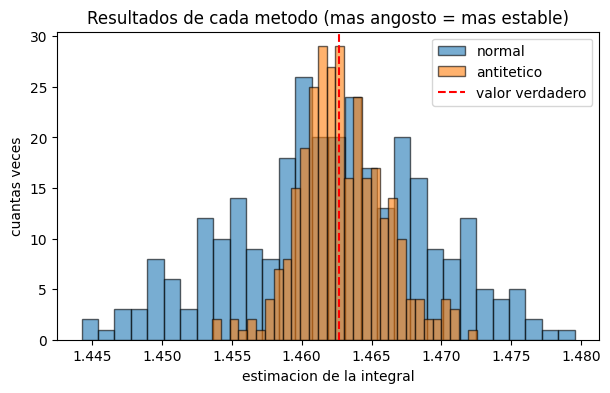

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(resultados_normal, bins=30, alpha=0.6, label='normal', edgecolor='black')
plt.hist(resultados_anti, bins=30, alpha=0.6, label='antitetico', edgecolor='black')
plt.axvline(verdadero, color='red', linestyle='--', label='valor verdadero')
plt.title("Resultados de cada metodo (mas angosto = mas estable)")
plt.xlabel("estimacion de la integral")
plt.ylabel("cuantas veces")
plt.legend()
plt.show()

Los dos métodos dan un resultado cercano al verdadero (alrededor de 1.4627), pero el método antitético es más estable (sus resultados brincan bastante menos). Esto pasa porque la función sube siempre, así que `u` y su espejo `1 - u` se compensan


# 3. Bootstrap y Jackknife

Tenemos esta muestra de 12 tiempos de entrega vista en clase:

$$\{35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40\}$$

Queremos saber la **media** y, sobre todo, qué tan confiable es esa media. Como solo tenemos una muestra, reaprovechamos esos mismos datos


In [ ]:
import numpy as np

# la muestra de la clase
datos = [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]
n = len(datos)

media_original = np.mean(datos)
desv_muestral = np.std(datos, ddof=1)        # desviacion estandar (divide entre n-1)
error_clasico = desv_muestral / np.sqrt(n)   # formula de siempre

print("Media de la muestra        :", media_original)
print("Desviacion estandar        :", round(desv_muestral, 4))
print("Error estandar (formula)   :", round(error_clasico, 4))

Media de la muestra        : 40.0
Desviacion estandar        : 3.1623
Error estandar (formula)   : 0.9129


## Bootstrap

Tratamos nuestra muestra como si fuera "toda la población" y sacamos muchas muestras nuevas a partir de ella, eligiendo al azar y con reemplazo.
Seguimos los pasos de la clase:

1. Generamos 1000 muestras del mismo tamaño (12 datos), eligiendo al azar con reemplazo
2. A cada muestra le sacamos su media
3. Al final calculamos: la media de esas 1000 medias, su desviación estándar (el error estándar bootstrap) y los percentiles 2.5 % y 97.5 %, que forman el intervalo de confianza del 95 %


In [ ]:
np.random.seed(7)
B = 1000              # cuantas muestras bootstrap

medias_boot = []
for b in range(B):
    # armamos una muestra nueva eligiendo 12 datos al azar, con reemplazo
    muestra = []
    for j in range(n):
        muestra.append(np.random.choice(datos))   # un dato al azar
    medias_boot.append(np.mean(muestra))

print("Listo. Generamos", len(medias_boot), "medias.")
print("Primeras 5:", [round(float(x), 3) for x in medias_boot[:5]])

Listo. Generamos 1000 medias.
Primeras 5: [40.167, 40.5, 39.25, 39.333, 39.167]


In [ ]:
media_boot = np.mean(medias_boot)            # media de las 1000 medias
error_boot = np.std(medias_boot, ddof=1)     # error estandar bootstrap
limite_bajo = np.percentile(medias_boot, 2.5)
limite_alto = np.percentile(medias_boot, 97.5)

print("Media de las 1000 medias     :", round(media_boot, 4))
print("Error estandar bootstrap     :", round(error_boot, 4))
print("Intervalo de confianza 95%   : de", round(limite_bajo, 4), "a", round(limite_alto, 4))

Media de las 1000 medias     : 39.9812
Error estandar bootstrap     : 0.8757
Intervalo de confianza 95%   : de 38.25 a 41.6687


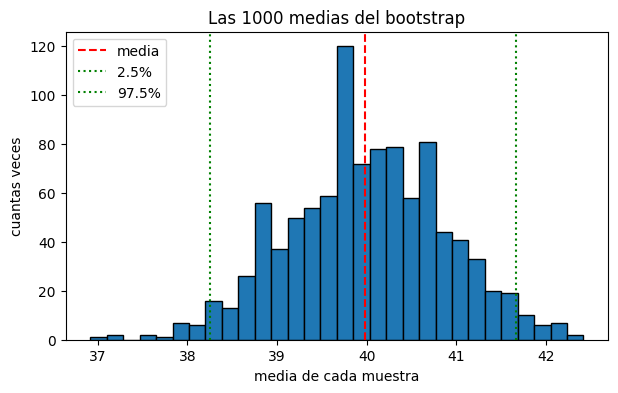

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(medias_boot, bins=30, edgecolor='black')
plt.axvline(media_boot, color='red', linestyle='--', label='media')
plt.axvline(limite_bajo, color='green', linestyle=':', label='2.5%')
plt.axvline(limite_alto, color='green', linestyle=':', label='97.5%')
plt.title("Las 1000 medias del bootstrap")
plt.xlabel("media de cada muestra")
plt.ylabel("cuantas veces")
plt.legend()
plt.show()

## Jackknife

Aún más sencillo: vamos quitando un dato a la veZ. Con 12 datos hacemos 12 muestras de 11 datos (cada una sin uno distinto) y a cada una le sacamos la media. Con esas 12 medias calculamos:

- La media de todas ellas.
- El sesgo (qué tanto se corre respecto a la media original): `(n-1) * (media_jack - media_original)`


El error estándar, con esta fórmula:

$$EE = \sqrt{\frac{n-1}{n}\sum (\text{cada media} - \text{media jackknife})^2}.$$


In [ ]:
medias_jack = []
for i in range(n):
    # muestra sin el dato que esta en la posicion i
    sin_i = datos[:i] + datos[i+1:]
    medias_jack.append(np.mean(sin_i))

media_jack = np.mean(medias_jack)

# error estandar: sumamos las diferencias al cuadrado con un bucle
suma = 0.0
for m in medias_jack:
    suma = suma + (m - media_jack) ** 2
error_jack = np.sqrt((n - 1) / n * suma)

# sesgo
sesgo_jack = (n - 1) * (media_jack - media_original)

print("Medias quitando un dato:")
print([round(float(x), 3) for x in medias_jack])
print()
print("Media jackknife       :", round(media_jack, 4))
print("Sesgo jackknife       :", round(sesgo_jack, 6))
print("Error estandar jackknife:", round(error_jack, 4))

Medias quitando un dato:
[40.455, 39.818, 40.182, 40.0, 39.545, 40.273, 40.091, 39.909, 39.636, 40.364, 39.727, 40.0]

Media jackknife       : 40.0
Sesgo jackknife       : 0.0
Error estandar jackknife: 0.9129


## Comparando los tres errores estándar

In [ ]:
print("Con la formula de siempre :", round(error_clasico, 4))
print("Con bootstrap             :", round(error_boot, 4))
print("Con jackknife             :", round(error_jack, 4))

Con la formula de siempre : 0.9129
Con bootstrap             : 0.8757
Con jackknife             : 0.9129


Los tres caminos dan un error estándar muy parecido (alrededor de 0.9). Detalles:

- Para la media, el jackknife da exactamente lo mismo que la fórmula de siempre, y su sesgo es **cero** (la media no se desvía). Eso nos confirma que el código está bien
- El bootstrap además nos regala una gráfica completa de cómo se reparte la media y un **intervalo de confianza** (aquí salió más o menos de 38.3 a 41.8) sin tener que suponer que los datos son normales
